In [1]:
import sys
!{sys.executable} -m pip install pandas scikit-learn vaderSentiment fastapi uvicorn wordcloud matplotlib seaborn nltk

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data (only runs once)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))

# ── Load dataset ──
# Place complaints_processed.csv in the SAME folder as this notebook
df = pd.read_csv(r"C:\Users\parth\Downloads\complaints_processed.csv\complaints_processed.csv")

# ── Clean text with Lemmatization ──
# Lemmatization converts words to their root form: "running" -> "run"
def clean_text(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r"http\S+", "", text)             # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)        # remove special chars
    words = text.split()
    # remove stopwords and lemmatize each word
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["narrative"].apply(clean_text)

print(df.head())

   Unnamed: 0           product  \
0           0       credit_card   
1           1       credit_card   
2           2    retail_banking   
3           3  credit_reporting   
4           4  credit_reporting   

                                           narrative  \
0  purchase order day shipping amount receive pro...   
1  forwarded message date tue subject please inve...   
2  forwarded message cc sent friday pdt subject f...   
3  payment history missing credit report speciali...   
4  payment history missing credit report made mis...   

                                          clean_text  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message sent friday pdt subject fina...  
3  payment history missing credit report speciali...  
4  payment history missing credit report made mis...  


In [3]:
print(df.shape)
print(df['product'].value_counts())

(162421, 4)
product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


In [4]:
print(df.isnull().sum())

Unnamed: 0     0
product        0
narrative     10
clean_text     0
dtype: int64


In [5]:
df = df.dropna()

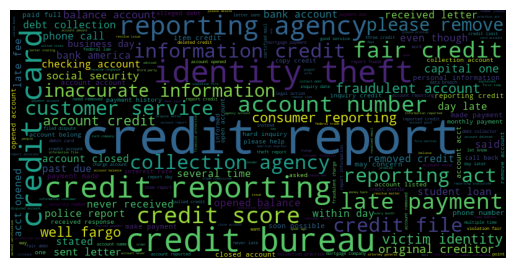

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

print(vectorizer.get_feature_names_out())

['account' 'company' 'credit' 'credit report' 'information' 'payment'
 'report' 'reporting' 'time' 'would']


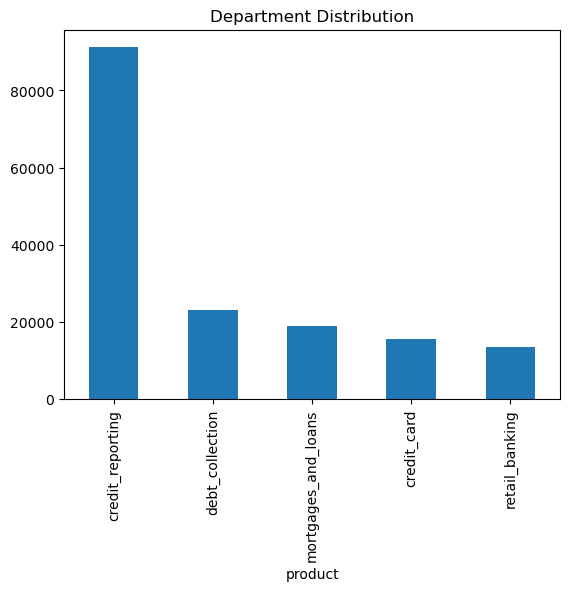

In [8]:
import matplotlib.pyplot as plt

df['product'].value_counts().plot(kind='bar')
plt.title("Department Distribution")
plt.show()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['product'])

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model (fixed convergence issue)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [10]:
# Cross-Validation
# Instead of trusting one train/test split, we test the model 5 times
# on different parts of the data to confirm it generalises well.
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Cross-Validation Accuracy per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std  Accuracy : {cv_scores.std():.4f}")

Cross-Validation Accuracy per fold:
  Fold 1: 0.8708
  Fold 2: 0.8714
  Fold 3: 0.8715
  Fold 4: 0.8736
  Fold 5: 0.8708
Mean Accuracy : 0.8716
Std  Accuracy : 0.0010


## Week 3 – Sentiment Analysis: Trained ML Model


In [11]:
# Step 1: Auto-label sentiment using VADER 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vader_label(text):
    score = vader.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment_label'] = df['narrative'].apply(vader_label)
print("Sentiment distribution (auto-labeled):")
print(df['sentiment_label'].value_counts())
print(f"\nTotal labelled samples: {len(df)}")

Sentiment distribution (auto-labeled):
sentiment_label
Positive    89137
Negative    63834
Neutral      9440
Name: count, dtype: int64

Total labelled samples: 162411


In [12]:
# Step 2: Train a supervised Sentiment Classifier 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Dedicated TF-IDF for sentiment (kept separate from department model)
tfidf_sentiment = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_sent = tfidf_sentiment.fit_transform(df['clean_text'])

le_sentiment = LabelEncoder()
y_sent = le_sentiment.fit_transform(df['sentiment_label'])   # Negative=0, Neutral=1, Positive=2

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

# class_weight='balanced' handles Neutral class imbalance
sentiment_model = LogisticRegression(max_iter=1000, class_weight='balanced')
sentiment_model.fit(X_s_train, y_s_train)

print("Sentiment classifier trained!")
print(f"Classes: {le_sentiment.classes_}")

Sentiment classifier trained!
Classes: ['Negative' 'Neutral' 'Positive']


Macro F1-Score (Sentiment Model): 0.7554

              precision    recall  f1-score   support

    Negative       0.89      0.84      0.86     12767
     Neutral       0.37      0.79      0.50      1888
    Positive       0.94      0.86      0.90     17828

    accuracy                           0.85     32483
   macro avg       0.73      0.83      0.76     32483
weighted avg       0.89      0.85      0.86     32483



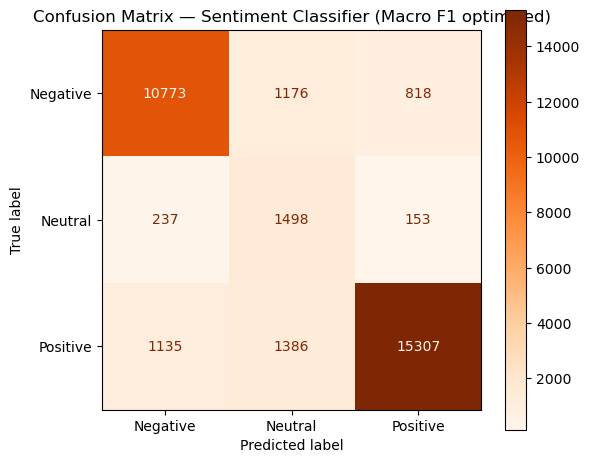

In [13]:
# Step 3: Evaluate — Macro F1-score + Confusion Matrix 
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score)

y_s_pred = sentiment_model.predict(X_s_test)

# Macro F1 — project KPI: ensures minority class (Neutral/Critical) is evaluated fairly
macro_f1 = f1_score(y_s_test, y_s_pred, average='macro')
print(f"Macro F1-Score (Sentiment Model): {macro_f1:.4f}\n")

# Full classification report
print(classification_report(y_s_test, y_s_pred, target_names=le_sentiment.classes_))

# Confusion Matrix
cm_s = confusion_matrix(y_s_test, y_s_pred)
disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s, display_labels=le_sentiment.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp_s.plot(cmap="Oranges", ax=ax)
plt.title("Confusion Matrix — Sentiment Classifier (Macro F1 optimised)")
plt.tight_layout()
plt.show()

In [14]:
# Step 4: Prediction helper — uses the TRAINED sentiment model 
def get_sentiment(text):
    """
    Classifies text sentiment using the trained Logistic Regression model.
    Returns: 'Positive' | 'Neutral' | 'Negative'
    """
    cleaned = clean_text(text)
    vec     = tfidf_sentiment.transform([cleaned])
    return le_sentiment.inverse_transform(sentiment_model.predict(vec))[0]

# Quick smoke-test
print(get_sentiment("My account was hacked and money was stolen!"))   # Negative
print(get_sentiment("Everything is working perfectly, thank you!"))    # Positive
print(get_sentiment("I would like to update my address."))             # Neutral

Negative
Positive
Positive


In [15]:
# Priority Scoring — keyword-enhanced urgency detection 
def get_priority(text, sentiment):
    """
    Returns: 'Critical' | 'High' | 'Medium' | 'Low'
    Critical  — fraud, legal threats, life/safety, escalation keywords
    High      — payment failures, account blocks, long wait times
    Medium    — neutral sentiment with no urgent keywords
    Low       — positive feedback
    """
    text_lower = text.lower()

    critical_words = [
        "urgent", "urgently", "urgency", "immediately", "immediate",
        "asap", "right now", "as soon as possible", "emergency", "critical",
        "stolen", "theft", "robbery", "fraud", "fraudulent", "scam", "cheated",
        "hacked", "hack", "hacking", "cyber attack", "phishing",
        "unauthorized transaction", "unauthorized access", "identity theft",
        "data breach", "leaked data", "police", "fir", "legal action",
        "court", "lawsuit", "sue", "lawyer", "consumer court", "rbi complaint",
        "banking ombudsman", "legal notice", "life", "death", "dying",
        "hospital", "medical", "accident", "danger", "dangerous", "threat",
        "all money gone", "entire savings", "life savings", "account emptied",
        "already complained", "complaint not resolved", "second complaint",
        "third complaint", "escalate", "escalating", "escalation",
        "higher authority", "senior manager", "ceo", "nodal officer",
        "deadline", "due date", "expiry", "expires today",
    ]

    high_words = [
        "not working", "not functioning", "stopped working",
        "transaction failed", "payment failed", "transfer failed",
        "money deducted", "amount deducted", "balance deducted",
        "refund pending", "refund not received", "waiting for refund",
        "account blocked", "account locked", "card blocked",
        "card not working", "atm not working", "otp not received",
        "emi bounced", "cheque bounced", "overcharged", "double charged",
        "wrong amount", "not received", "never received", "still not received",
        "no response", "no reply", "nobody helping",
        "days", "weeks", "months", "long time",
    ]

    for word in critical_words:
        if word in text_lower:
            return "Critical"

    for word in high_words:
        if word in text_lower:
            return "High"

    if sentiment == "Negative":
        return "High"
    elif sentiment == "Positive":
        return "Low"
    return "Medium"

print("Priority function defined.")

Priority function defined.


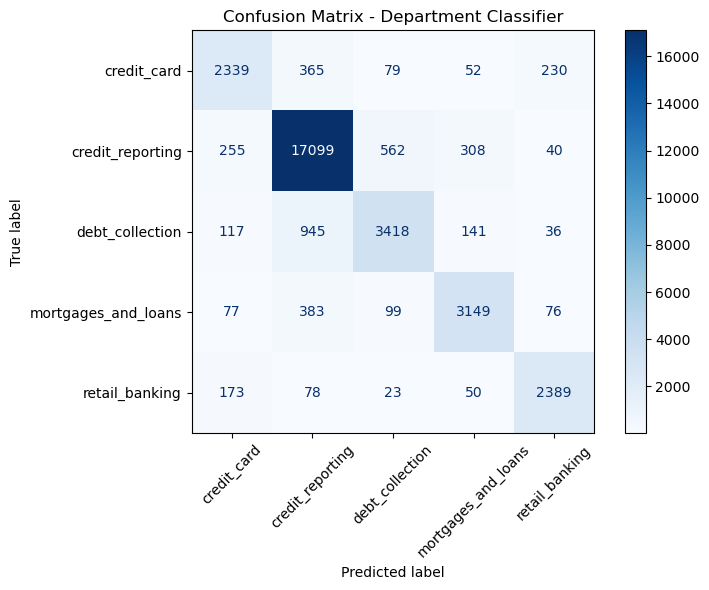

                     precision    recall  f1-score   support

        credit_card       0.79      0.76      0.78      3065
   credit_reporting       0.91      0.94      0.92     18264
    debt_collection       0.82      0.73      0.77      4657
mortgages_and_loans       0.85      0.83      0.84      3784
     retail_banking       0.86      0.88      0.87      2713

           accuracy                           0.87     32483
          macro avg       0.85      0.83      0.84     32483
       weighted avg       0.87      0.87      0.87     32483



In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

# Confusion Matrix with department names
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Department Classifier")
plt.tight_layout()
plt.show()

# Full report
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [17]:
# Serialise all models 
import pickle

# Department classifier artefacts
pickle.dump(model,            open('department_model.pkl',     'wb'))
pickle.dump(tfidf,            open('tfidf_vectorizer.pkl',     'wb'))
pickle.dump(le,               open('label_encoder.pkl',        'wb'))

# Sentiment classifier artefacts (new — Week 3)
pickle.dump(sentiment_model,  open('sentiment_model.pkl',      'wb'))
pickle.dump(tfidf_sentiment,  open('tfidf_sentiment.pkl',      'wb'))
pickle.dump(le_sentiment,     open('le_sentiment.pkl',         'wb'))

print("All 6 model artefacts saved successfully.")

All 6 model artefacts saved successfully.


In [18]:
# End-to-end inference using the trained sentiment model 
def predict_complaint(text):
    # Department prediction
    text_clean = clean_text(text)
    text_tfidf = tfidf.transform([text_clean])
    pred       = model.predict(text_tfidf)
    department = le.inverse_transform(pred)[0]

    # Sentiment via trained model (not VADER)
    sentiment = get_sentiment(text)

    # Priority via keyword + sentiment
    priority  = get_priority(text, sentiment)

    return {
        "department": department,
        "sentiment":  sentiment,
        "priority":   priority,
    }

# Test cases
tests = [
    "I cannot use my credit card and money was deducted twice!",
    "Thank you, my loan issue was resolved quickly.",
    "I need to update my address on the mortgage account.",
    "URGENT: my account has been hacked, all money stolen, filing FIR today!",
]

for t in tests:
    print(predict_complaint(t))
    print()

{'department': 'credit_card', 'sentiment': 'Neutral', 'priority': 'Medium'}

{'department': 'credit_reporting', 'sentiment': 'Positive', 'priority': 'Critical'}

{'department': 'credit_reporting', 'sentiment': 'Neutral', 'priority': 'Medium'}

{'department': 'retail_banking', 'sentiment': 'Negative', 'priority': 'Critical'}



In [19]:
# FastAPI — run the API server 
# Ensure app.py is in the same folder, then run:
#   pip install fastapi uvicorn vaderSentiment
#   python -m uvicorn app:app --reload
#
# Interactive docs available at:
#   http://127.0.0.1:8000/docs

In [20]:
df.head()

,Unnamed: 0,product,narrative,clean_text,label,sentiment_label
0,0,credit_card,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...,0,Positive
1,1,credit_card,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...,0,Positive
2,2,retail_banking,forwarded message cc sent friday pdt subject f...,forwarded message sent friday pdt subject fina...,4,Negative
3,3,credit_reporting,payment history missing credit report speciali...,payment history missing credit report speciali...,1,Neutral
4,4,credit_reporting,payment history missing credit report made mis...,payment history missing credit report made mis...,1,Neutral
